In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [34]:
import zipfile
import os

# Assuming the uploaded file is archive.zip and it's in the current directory (or /content/)
# List the files in the current directory to confirm its presence if needed:
# !ls

# Unzip the archive.zip file
zip_file_path = '/content/archive.zip'
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('/content/') # Extract to the current content directory
    print(f"Successfully unzipped {zip_file_path}")
    # List files again to confirm extraction
    !ls /content/
else:
    print(f"Error: {zip_file_path} not found.")


Successfully unzipped /content/archive.zip
 archive.zip	        credits.csv.zip      sample_data
'credits.csv (1).zip'   netflix_titles.csv


In [35]:
##load dataset
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [37]:
##Data cleaning
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [38]:
##fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

/tmp/ipykernel_193/145749986.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_193/145749986.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [41]:
##convert date column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='mixed')


In [42]:
##Feature engineering
#Create year added column
df['year_added'] = df['date_added'].dt.year
#Create month added column
df['month_added'] = df['date_added'].dt.month


<Axes: xlabel='type', ylabel='count'>

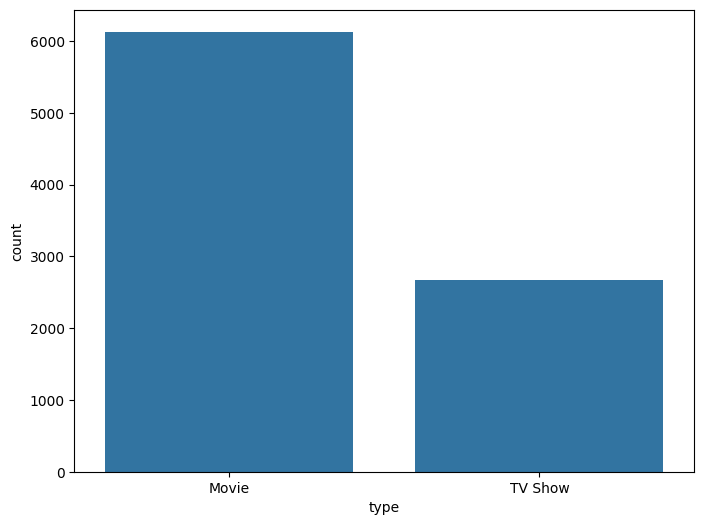

In [43]:
##Exploratory Data Analysis
#Content Type Distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='type')

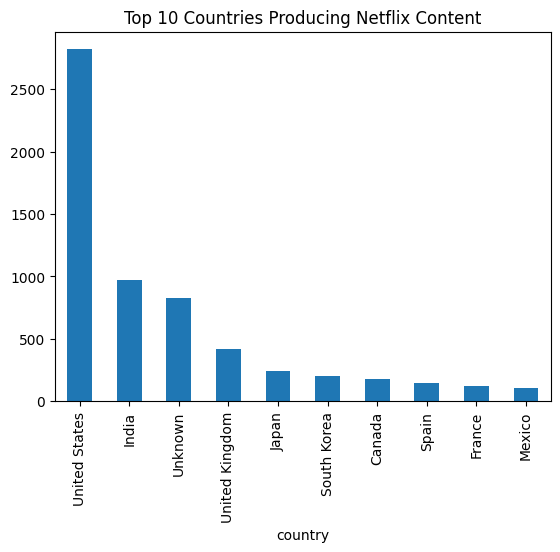

In [45]:
#Top Countries Producing Content
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Netflix Content")
plt.show()

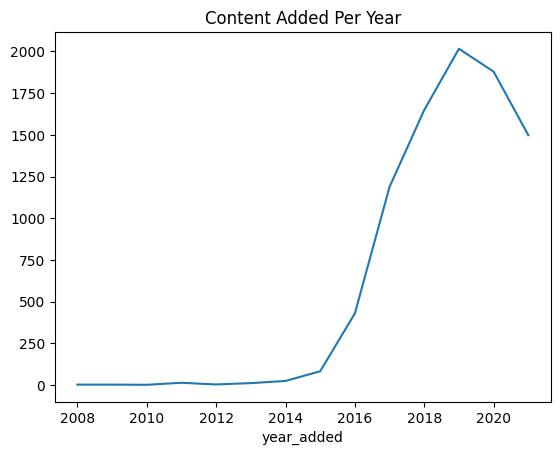

In [46]:
##Content Added Per Year
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Per Year")
plt.show()

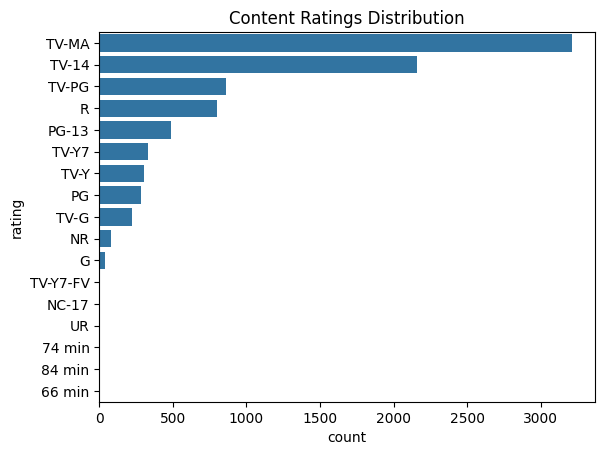

In [47]:
##Most Common Ratings
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Content Ratings Distribution")
plt.show()

In [48]:
##Clustering (KMeans)
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
df['duration_num'] = df['duration'].str.extract('(\d+)')
df['duration_num'] = pd.to_numeric(df['duration_num'], errors='coerce')

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_193/1163022639.py:4: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)')


In [49]:
##Create feature dataset
X = df[['release_year','duration_num']].dropna()

In [50]:
##Apply clustering
kmeans = KMeans(n_clusters=3, random_state=42)
X['cluster'] = kmeans.fit_predict(X)

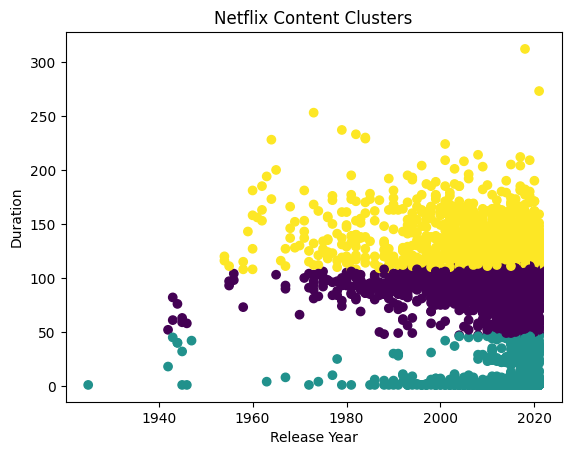

In [51]:
##Plot clustering
plt.scatter(X['release_year'], X['duration_num'], c=X['cluster'])
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.title("Netflix Content Clusters")
plt.show()

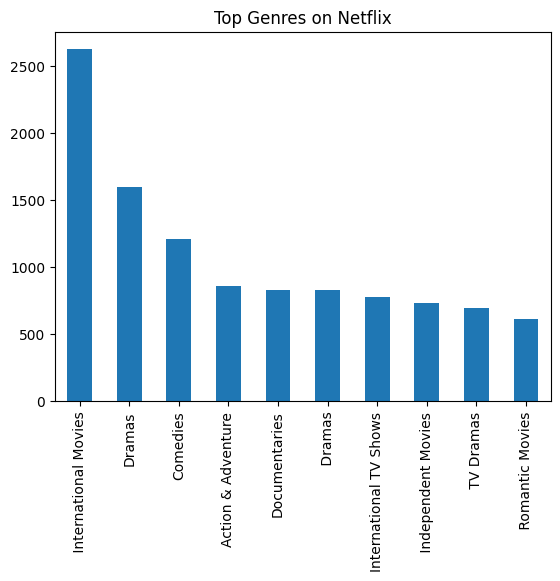

In [52]:
##Visualization Dashboard
genres = df['listed_in'].str.split(',', expand=True).stack()

genres.value_counts().head(10).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.show()